In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display

from src.data_processing import clean_text
from src.bag_of_words import NumpyBagOfWords
from src.hyperopt import build_grid
from src.models_numpy.logistic_regression import LogisticRegression

df = pd.read_csv("../data/processed/dataset_kaggle_daigt_processed.csv", sep=";")

label_map = {label: i for i, label in enumerate(df['Label'].unique())}
inv_label_map = {i: label for label, i in label_map.items()}
df['label_id'] = df['Label'].map(label_map)

print("A limpar textos...")
df['text_clean'] = df['Text'].apply(clean_text)

num_classes = len(label_map)
y_onehot = np.eye(num_classes)[df['label_id'].values]

X_train, X_val, y_train_oh, y_val_oh = train_test_split(
    df['text_clean'], y_onehot, test_size=0.2, random_state=42, stratify=df['label_id']
)

_, _, y_train_labels, y_val_labels = train_test_split(
    df['text_clean'], df['label_id'], test_size=0.2, random_state=42, stratify=df['label_id']
)

print(f"Treino: {len(X_train)} | Validação: {len(X_val)}")

A limpar textos...
Treino: 4108 | Validação: 1028


In [ ]:
param_grid_lr = {
    'max_words': [2000, 3000, 3500],
    'learning_rate': [0.01, 0.05, 0.1],
    'epochs': [500, 600]
}

resultados_lr = []

print("=== A Iniciar Grid Search: Regressão Logística ===")
for params in build_grid(param_grid_lr):
    print(f"\nA testar: {params}")
    inicio = time.time()
    
    bow = NumpyBagOfWords(max_words=params['max_words'])
    X_tr = bow.fit_transform(X_train)
    X_te = bow.transform(X_val)
    
    model = LogisticRegression(
        n_features=X_tr.shape[1], 
        n_classes=num_classes, 
        learning_rate=params['learning_rate'], 
        epochs=params['epochs']
    )
    
    history = model.fit(X_tr, y_train_oh, val_data=(X_te, y_val_oh), verbose=False)
    
    val_acc_final = history['val_acc'][-1]
    val_loss_final = history['val_loss'][-1]
    tempo_gasto = time.time() - inicio
    
    resultados_lr.append({
        'Max Words': params['max_words'],
        'Learning Rate': params['learning_rate'],
        'Epochs': params['epochs'],
        'Val Accuracy': val_acc_final,
        'Val Loss': val_loss_final,
        'Tempo (s)': round(tempo_gasto, 1)
    })
    print(f" -> Val Acc: {val_acc_final:.4f} | Val Loss: {val_loss_final:.4f} | Tempo: {tempo_gasto:.1f}s")

df_grid_lr = pd.DataFrame(resultados_lr).sort_values(by=['Val Accuracy', 'Val Loss'], ascending=[False, True])
display(df_grid_lr)

A treinar o Modelo LR (Words: 2000, LR: 0.1, Epochs: 750)...
Epoch 20/750 | Loss: 0.5204 Acc: 0.8851 | Val Loss: 0.5513 Val Acc: 0.8346
Epoch 40/750 | Loss: 0.3677 Acc: 0.9211 | Val Loss: 0.4199 Val Acc: 0.8901
Epoch 60/750 | Loss: 0.2984 Acc: 0.9408 | Val Loss: 0.3618 Val Acc: 0.8979
Epoch 80/750 | Loss: 0.2551 Acc: 0.9540 | Val Loss: 0.3262 Val Acc: 0.9066
Epoch 100/750 | Loss: 0.2247 Acc: 0.9630 | Val Loss: 0.3017 Val Acc: 0.9125
Epoch 120/750 | Loss: 0.2019 Acc: 0.9681 | Val Loss: 0.2836 Val Acc: 0.9232
Epoch 140/750 | Loss: 0.1839 Acc: 0.9715 | Val Loss: 0.2695 Val Acc: 0.9261
Epoch 160/750 | Loss: 0.1692 Acc: 0.9754 | Val Loss: 0.2583 Val Acc: 0.9280
Epoch 180/750 | Loss: 0.1570 Acc: 0.9786 | Val Loss: 0.2490 Val Acc: 0.9300
Epoch 200/750 | Loss: 0.1466 Acc: 0.9813 | Val Loss: 0.2413 Val Acc: 0.9280
Epoch 220/750 | Loss: 0.1376 Acc: 0.9834 | Val Loss: 0.2347 Val Acc: 0.9300
Epoch 240/750 | Loss: 0.1297 Acc: 0.9849 | Val Loss: 0.2290 Val Acc: 0.9300
Epoch 260/750 | Loss: 0.1228 Ac

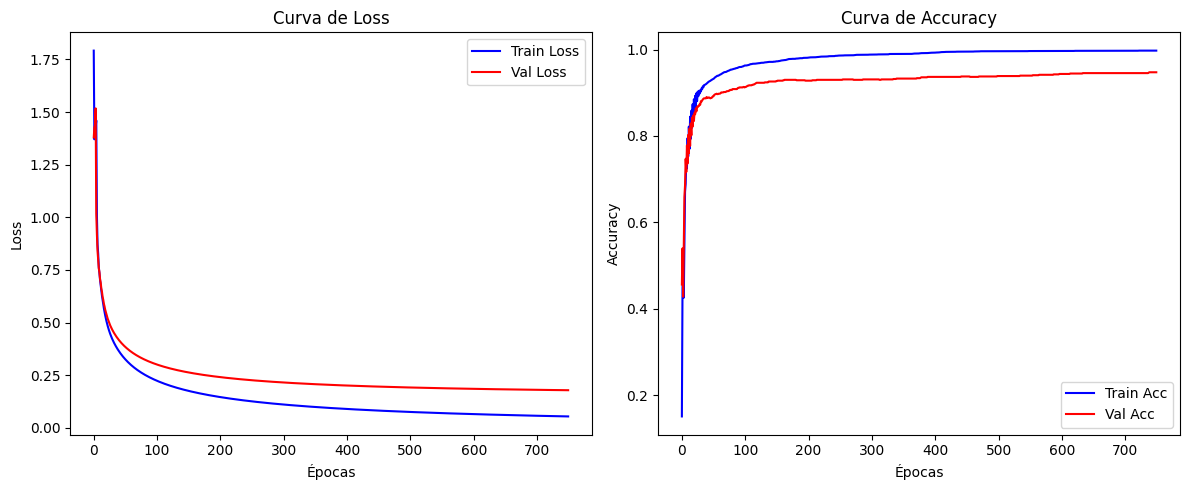

In [5]:
MELHOR_MAX_WORDS = 2000
MELHOR_LR = 0.1
MELHORES_EPOCAS = 750


print(f"A treinar o Modelo LR (Words: {MELHOR_MAX_WORDS}, LR: {MELHOR_LR}, Epochs: {MELHORES_EPOCAS})...")

bow_final = NumpyBagOfWords(max_words=MELHOR_MAX_WORDS)
X_train_final = bow_final.fit_transform(X_train)
X_val_final = bow_final.transform(X_val)

model_final = LogisticRegression(
    n_features=X_train_final.shape[1], 
    n_classes=num_classes, 
    learning_rate=MELHOR_LR, 
    epochs=MELHORES_EPOCAS
)

history_final = model_final.fit(X_train_final, y_train_oh, val_data=(X_val_final, y_val_oh), verbose=True)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_final['train_loss'], label='Train Loss', color='blue')
plt.plot(history_final['val_loss'], label='Val Loss', color='red')
plt.title('Curva de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_final['train_acc'], label='Train Acc', color='blue')
plt.plot(history_final['val_acc'], label='Val Acc', color='red')
plt.title('Curva de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Relatório de Classificação Final (Logistic Regression):
              precision    recall  f1-score   support

   Anthropic       0.97      1.00      0.99       155
      Google       0.99      0.99      0.99       147
       Human       0.97      0.94      0.96       197
        Meta       0.95      0.89      0.92       176
     Mistral       0.88      0.91      0.90       183
      OpenAI       0.94      0.96      0.95       170

    accuracy                           0.95      1028
   macro avg       0.95      0.95      0.95      1028
weighted avg       0.95      0.95      0.95      1028



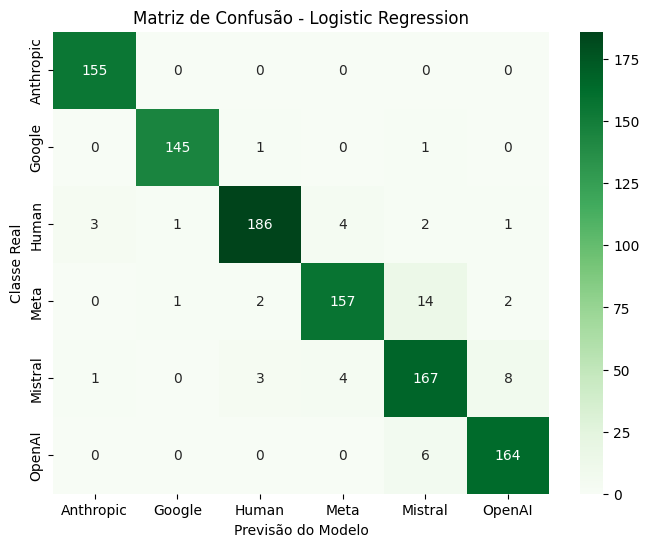

Modelo guardado com sucesso em '../models/logistic_regression_final.npz'


In [7]:
y_pred_final = model_final.predict(X_val_final)

nomes_classes = [inv_label_map[i] for i in range(num_classes)]

print("\nRelatório de Classificação Final (Logistic Regression):")
print(classification_report(y_val_labels, y_pred_final, target_names=nomes_classes))

# Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val_labels, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=nomes_classes, yticklabels=nomes_classes, cmap='Greens')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão - Logistic Regression')
plt.show()

import os
os.makedirs("../saved_models", exist_ok=True)
model_final.save("../saved_models/logistic_regression_final.npz")
bow_final.save("../saved_models/logistic_bow_model.pkl")
print("Modelo guardado com sucesso em '../models/logistic_regression_final.npz'")

In [8]:
print("Melhor Val Accuracy LR:", max(history_final['val_acc']))
print("Melhor Val Loss LR:", min(history_final['val_loss']))

Melhor Val Accuracy LR: 0.9474708171206225
Melhor Val Loss LR: 0.17889562753963276


In [9]:
import os
os.makedirs("../submissions/submissao1", exist_ok=True)
model_final.save("../submissions/submissao1/logistic_regression_final.npz")
bow_final.save("../submissions/submissao1/logistic_bow_model.pkl")
print("Artefactos LR guardados em ../submissions/submissao1/")

Artefactos LR guardados em ../submissions/submissao1/
